# 01C 训练、验证与生成
对应 **L01.06–L01.08**，并回到 L01.01 的训练前后对照。

从随机参数训练一个真正的微型字符级 Transformer。默认 240 次更新，CPU 运行；耗时取决于电脑。请记录自己实测的时间，不要照抄示例时间。

实验语料是课程自编短文，结构高度重复。Loss 改善只能说明这份数据上的预测改善，不能证明获得通用知识或 Agent 能力。


## 学习路线与配套课件

实践 1C：训练、零学习率与生成（`L01-P03`）。

建议先完成本节概念正课，再进入本实践小节。这个 Notebook 可用独立新内核从头运行。先预测，再执行代码、修改一个条件并解释结果。

对应课件稳定编号：L01.06-S01、L01.06-S02、L01.06-S03、L01.06-S04、L01.06-S05、L01.07-S01、L01.07-S02、L01.07-S03、L01.07-S04、L01.07-S05、L01.08-S01、L01.08-S02、L01.08-S03。页数调整不改变这些编号。

按“问题—代码—观察—练习—可复用结果”的顺序学习。先完成练习，再展开参考分析。回放、保存的真实记录和新的在线请求都会明确标注；在线请求默认关闭。

In [1]:
from pathlib import Path
import sys
# 无论从仓库根目录还是 Notebook 目录启动，都定位到同一份课程资料。
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "00-资料库使用说明.md").exists())
CHAPTER = ROOT / "01 大模型基础与最小训练实验"
import torch
from torch.nn import functional as F
torch.manual_seed(7)
torch.set_num_threads(2)
print("PyTorch:", torch.__version__, "；本实验使用 CPU")
import copy, json, math, time, hashlib, platform
from torch import nn


PyTorch: 2.8.0+cpu ；本实验使用 CPU


## 梯度与学习率的数值体验
先用一个参数拟合目标 3，损失为 (w−3)²。梯度指出局部变化方向。下面是普通 SGD 的单步公式，后面的真实模型使用 AdamW，更新公式更复杂。

**先预测：**学习率 0、0.1、1.2 分别会怎样？


### 一次梯度下降：公式与小算例

简单梯度下降：$$w_{new}=w_{old}-\eta\frac{\partial L}{\partial w}.$$

本例 $L=(w-3)^2$，梯度 $2(w-3)$。当 $w=0,\eta=0.1$，新参数为 $0.6$，新损失为 $5.76$。这是一维讲解例子；真实训练使用 AdamW。

用一个标量参数讲清更新方向。L=(w−3)²，导数为 2(w−3)。初始 w=0，梯度为 −6；沿负梯度方向更新，相当于向正方向走。学习率为 0.1 时，新 w=0−0.1×(−6)=0.6，损失由 9 变为 5.76。学习率为 0 时参数不变；学习率 1.2 时走到 7.2，越过最低点 3，损失增大。这是无动量、无权重衰减的梯度下降算例，说明梯度、方向和步长；后面的真实 Transformer 使用 AdamW，更新规则不等同于本式。请在 Notebook 改学习率并预测方向，避免只背 backward 与 step 的名字。

参考：https://docs.pytorch.org/docs/2.14/generated/torch.optim.SGD.html


In [2]:
for lr in [0.0,0.1,1.2]:
    w = torch.tensor(0.0,requires_grad=True)
    loss = (w-3).square()
    loss.backward()
    with torch.no_grad():
        updated = w - lr*w.grad
    print(f"lr={lr}: w={w.item():.1f}, gradient={w.grad.item():.1f}, "
          f"new_w={updated.item():.2f}, new_loss={(updated-3).square().item():.2f}")


lr=0.0: w=0.0, gradient=-6.0, new_w=0.00, new_loss=9.00
lr=0.1: w=0.0, gradient=-6.0, new_w=0.60, new_loss=5.76
lr=1.2: w=0.0, gradient=-6.0, new_w=7.20, new_loss=17.64


## 数据与模型
以下数据函数和模型代码与 01B、代码/tiny_lm.py 一致，放在 Notebook 中便于逐行修改。本份 Notebook 可以独立重跑。


In [3]:
def load_data(path):
    docs = json.loads(Path(path).read_text(encoding="utf-8"))
    train = [d["text"] for d in docs if d["split"] == "train"]
    valid = [d["text"] for d in docs if d["split"] == "valid"]
    assert not set(train) & set(valid), "训练与验证不能包含相同文档"
    vocab = ["<UNK>"] + sorted(set("\n".join(train)))
    stoi = {ch: i for i, ch in enumerate(vocab)}
    def encode(text):
        return torch.tensor([stoi.get(ch, 0) for ch in text], dtype=torch.long)
    return vocab, [encode(x) for x in train], [encode(x) for x in valid]


def windows(documents, context=32):
    # 窗口不能跨越文档边界；输入与标签错开一个位置。
    pairs = [(d[i:i+context], d[i+1:i+context+1])
             for d in documents for i in range(len(d)-context)]
    if not pairs:
        raise ValueError("文档必须长于上下文窗口")
    return torch.stack([p[0] for p in pairs]), torch.stack([p[1] for p in pairs])


In [4]:
class CausalAttention(nn.Module):
    def __init__(self, width, heads, context):
        super().__init__()
        assert width % heads == 0
        self.heads, self.head_dim = heads, width // heads
        self.qkv = nn.Linear(width, 3 * width)
        self.out = nn.Linear(width, width)
        self.register_buffer("mask", torch.tril(torch.ones(context, context, dtype=torch.bool)))

    def forward(self, x):
        batch, length, width = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        # [B,T,C] -> [B,H,T,D]，每个头学习不同的关系。
        q, k, v = [t.reshape(batch, length, self.heads, self.head_dim).transpose(1, 2)
                   for t in (q, k, v)]
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~self.mask[:length, :length], float("-inf"))
        weights = scores.softmax(dim=-1)
        mixed = (weights @ v).transpose(1, 2).contiguous().reshape(batch, length, width)
        return self.out(mixed)


class Block(nn.Module):
    def __init__(self, width, heads, context):
        super().__init__()
        self.norm1, self.norm2 = nn.LayerNorm(width), nn.LayerNorm(width)
        self.attention = CausalAttention(width, heads, context)
        self.ffn = nn.Sequential(nn.Linear(width, 4 * width), nn.GELU(), nn.Linear(4 * width, width))

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        return x + self.ffn(self.norm2(x))


class TinyLM(nn.Module):
    def __init__(self, vocab_size, width=48, heads=4, context=32):
        super().__init__()
        self.context = context
        self.token_embedding = nn.Embedding(vocab_size, width)
        self.position_embedding = nn.Embedding(context, width)
        self.block = Block(width, heads, context)
        self.norm = nn.LayerNorm(width)
        self.output = nn.Linear(width, vocab_size)

    def forward(self, ids):
        length = ids.shape[1]
        if not 0 < length <= self.context:
            raise ValueError("输入长度必须在上下文窗口内")
        pos = torch.arange(length, device=ids.device)
        x = self.token_embedding(ids) + self.position_embedding(pos)
        return self.output(self.norm(self.block(x)))  # [B,T,V]，返回 logits


## 完整训练与生成代码
重点定位 `zero_grad → backward → step`，并区分训练模式与 `no_grad` 评估。

每 40 步在固定的全部训练/验证窗口上评估一次；曲线连接真实测量点。训练时随机抽 batch，评估时不更新参数。模型只有一层，不使用 dropout，便于观察和复现。


![训练文本先形成输入和错开一位的目标。模型预测后计算 Loss，反向传播求梯度，优化器更新参数。回箭头表示下一次迭代使用新参数；下面逐行对照实际代码。](资源/training-loop-v2.png)

训练文本先形成输入和错开一位的目标。模型预测后计算 Loss，反向传播求梯度，优化器更新参数。回箭头表示下一次迭代使用新参数；下面逐行对照实际代码。


In [5]:
@torch.no_grad()
def evaluate(model, pairs):
    model.eval()
    total, count = 0., 0
    for x, y in zip(pairs[0].split(128), pairs[1].split(128)):
        loss = F.cross_entropy(model(x).reshape(-1, model.output.out_features), y.reshape(-1), reduction="sum")
        total += loss.item()
        count += y.numel()
    return total / count


@torch.no_grad()
def generate(model, vocab, prefix="学习", steps=60, temperature=0.8, seed=11):
    if temperature <= 0:
        raise ValueError("temperature 必须大于 0；本函数不把 0 当作贪心解码")
    model.eval()
    stoi = {ch: i for i, ch in enumerate(vocab)}
    ids = torch.tensor([[stoi.get(ch, 0) for ch in prefix]], dtype=torch.long)
    if ids.shape[1] == 0:
        raise ValueError("前缀不能为空")
    rng = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        logits = model(ids[:, -model.context:])[:, -1, :]
        next_id = torch.multinomial((logits / temperature).softmax(-1), 1, generator=rng)
        ids = torch.cat([ids, next_id], dim=1)
    return "".join(vocab[i] for i in ids[0].tolist())


def train_experiment(data_path, steps=240, lr=0.003, seed=7, context=32, width=48, batch_size=16):
    torch.set_num_threads(2)
    torch.manual_seed(seed)
    vocab, train_docs, valid_docs = load_data(data_path)
    train_pairs, valid_pairs = windows(train_docs, context), windows(valid_docs, context)
    model = TinyLM(len(vocab), width=width, context=context)
    initial_state = copy.deepcopy(model.state_dict())
    before = generate(model, vocab)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    rng = torch.Generator().manual_seed(seed + 1)
    history, started = [], time.perf_counter()
    for step in range(steps + 1):
        if step % 40 == 0 or step == steps:
            history.append({"step": step, "train_loss": evaluate(model, train_pairs),
                            "valid_loss": evaluate(model, valid_pairs)})
        if step == steps:
            break
        model.train()
        index = torch.randint(len(train_pairs[0]), (batch_size,), generator=rng)
        x, y = train_pairs[0][index], train_pairs[1][index]
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, len(vocab)), y.reshape(-1))
        optimizer.zero_grad(set_to_none=True)  # 清除上一批累积的梯度
        loss.backward()                      # 自动求导，得到每个参数的梯度
        optimizer.step()                     # AdamW 按优化器规则更新参数
    report = {"seed": seed, "steps": steps, "lr": lr, "context": context, "width": width,
              "batch_size": batch_size, "parameters": sum(p.numel() for p in model.parameters()),
              "vocab_size": len(vocab), "train_documents": len(train_docs), "valid_documents": len(valid_docs),
              "train_windows": len(train_pairs[0]), "valid_windows": len(valid_pairs[0]),
              "valid_unknown_ratio": sum((d == 0).sum().item() for d in valid_docs) / sum(len(d) for d in valid_docs),
              "elapsed_seconds": round(time.perf_counter() - started, 3), "device": "cpu",
              "python": platform.python_version(), "torch": torch.__version__, "platform": platform.platform(),
              "data_sha256": hashlib.sha256(Path(data_path).read_bytes()).hexdigest(),
              "history": history, "before": before, "after": generate(model, vocab),
              "temperatures": {str(t): generate(model, vocab, temperature=t) for t in (0.3, 0.8, 1.5)}}
    return model, vocab, report, initial_state


In [6]:
model, vocab, report, initial_state = train_experiment(CHAPTER/"数据/corpus.json")
print("参数量:", report["parameters"], "词表大小:", report["vocab_size"])
print("CPU 实测秒数:", report["elapsed_seconds"])
print("验证未知字符比例:", round(report["valid_unknown_ratio"],4))
for item in report["history"]:
    print(item)
# 作业输出放到忽略目录，不覆盖随课基线记录。
OUT = ROOT / ".local/student-runs/l01"
OUT.mkdir(parents=True,exist_ok=True)
(OUT/"training.json").write_text(json.dumps(report,ensure_ascii=False,indent=2),encoding="utf-8")
assert all(math.isfinite(x["train_loss"]) and math.isfinite(x["valid_loss"]) for x in report["history"])


参数量: 39701 词表大小: 101
CPU 实测秒数: 1.753
验证未知字符比例: 0.0
{'step': 0, 'train_loss': 4.774789836830246, 'valid_loss': 4.7549542018345425}
{'step': 40, 'train_loss': 1.2202891123271036, 'valid_loss': 1.4636190959385462}
{'step': 80, 'train_loss': 0.29569305298095216, 'valid_loss': 0.37168865544455393}
{'step': 120, 'train_loss': 0.1154523209897344, 'valid_loss': 0.1687586350100381}
{'step': 160, 'train_loss': 0.07664804782220228, 'valid_loss': 0.12558058755738394}
{'step': 200, 'train_loss': 0.059993449799314945, 'valid_loss': 0.1077871322631836}
{'step': 240, 'train_loss': 0.05045086561800715, 'valid_loss': 0.09423708702836718}


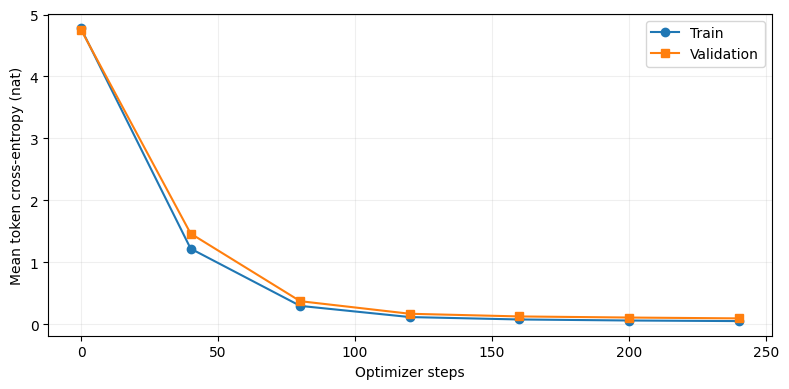

曲线反映自编小语料；文档不同，但共享句式。


In [7]:
import matplotlib.pyplot as plt
history = report["history"]
fig, ax = plt.subplots(figsize=(8,4))
ax.plot([x["step"] for x in history],[x["train_loss"] for x in history],"o-",label="Train")
ax.plot([x["step"] for x in history],[x["valid_loss"] for x in history],"s-",label="Validation")
ax.set(xlabel="Optimizer steps",ylabel="Mean token cross-entropy (nat)")
ax.legend(); ax.grid(alpha=0.2); fig.tight_layout()
plt.show()
print("曲线反映自编小语料；文档不同，但共享句式。")


## 同一前缀、同一采样设置的前后对照
先观察哪些短语更像语料，再找语义不通、反复重复或无法完成指令的地方。不要只截取最好的一次结果。


### 生成温度：公式与小算例

$$p_i(T)=\frac{\exp(z_i/T)}{\sum_j\exp(z_j/T)},\quad T>0.$$

同一教学 logits `[2,1,0]`：$T=0.5$ 时概率约 `[0.867,0.117,0.016]`；$T=1$ 时约 `[0.665,0.245,0.090]`。下方是实际模型的生成演示，输出不是这三个数字。

继续用同一组教学分数 2、1、0。温度为 1 时得到原来的概率；温度为 0.5 时，除温度后的分数为 4、2、0，概率约 0.867、0.117、0.016，最大候选的概率更高。这里比较的是同一组假设分数，不是下面真实训练模型的生成输出。温度只改变解码概率，不训练新参数，也不能保证事实正确。T 必须大于 0；本课函数不把 T=0 当作合法输入。理解分布变化后，再比较真实模型的不同温度续写，观察采样随机性与文本质量的关系。

参考：https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.softmax.html


In [8]:
print("训练前:", report["before"])
print("训练后:", report["after"])
for temperature, sample in report["temperatures"].items():
    print(f"temperature={temperature}: {sample}")
print("温度作用于推理时的 logits；这里没有重新训练模型。")


训练前: 学习错任也参序住到据务结，较程练想天记例录记条验条时是不修较下差别任输结写练时入能然一验文别变参成误帮件文不比运修答少和我少
训练后: 学习不只是记住答案，也要检查过程。数据太少时，模型可能记住例子，却不能完成新的任务。实验结果，结果。遇到错误时，先查看输入，
temperature=0.3: 学习不只是记住答案，也要检查过程。数据太少时，模型可能记住例子，却不能完成新的任务。实验结果，结果。遇到错误时，先查看输入，
temperature=0.8: 学习不只是记住答案，也要检查过程。数据太少时，模型可能记住例子，却不能完成新的任务。实验结果，结果。遇到错误时，先查看输入，
temperature=1.5: 学习任务小实验住文据，结束以程。不能记住答案，验结案，也要检下差别。数据写下任务。然后验结束以后，记录参数和结果。学错和我们
温度作用于推理时的 logits；这里没有重新训练模型。


### 温度改变分布，不更新模型参数

配套课件：L01.07-S03、L01.07-S04。

生成时使用 $p_i(T)=\mathrm{softmax}(z/T)_i$，本课要求 $T>0$。固定同一组 logits，只改温度，比较分布；然后再读上面真实训练模型的续写。一次文本样本不能代表整个分布。

In [9]:
case_logits = torch.tensor([2., 1., 0.])
for case_t in [0.5, 1.0, 2.0]:
    case_p = torch.softmax(case_logits / case_t, dim=-1)
    print("T =", case_t, "概率 =", [round(v, 4) for v in case_p.tolist()])
assert torch.softmax(case_logits / .5, dim=-1)[0] > torch.softmax(case_logits, dim=-1)[0]
print("本次训练最后一条:", report["history"][-1])
print("课件曲线来自课程历史训练记录；本 Notebook 的曲线来自本次 report。")


T = 0.5 概率 = [0.8668, 0.1173, 0.0159]
T = 1.0 概率 = [0.6652, 0.2447, 0.09]
T = 2.0 概率 = [0.5065, 0.3072, 0.1863]
本次训练最后一条: {'step': 240, 'train_loss': 0.05045086561800715, 'valid_loss': 0.09423708702836718}
课件曲线来自课程历史训练记录；本 Notebook 的曲线来自本次 report。


**结果解读**

T=0.5 时最高概率约 0.8668；T=1 时约 0.6652；T=2 时约 0.5065。温度越低越集中，但有限正温度不等于总选最大项。本次 report 才是本次训练证据，不能用保存截图代替。

**小练习**

为什么“换一个温度生成得更通顺”不能证明模型参数训练得更好？至少说出一个需要固定的条件。

<details><summary>完成后展开参考分析</summary>

模型参数没更新，只换了采样分布。比较训练前后应固定前缀、温度和采样设置，并结合验证 Loss 与多次样本。

</details>

公式与实现来源见 [配套素材来源](../../资料来源.md)。

### 练习：零学习率对照
用相同的初始参数和训练程序，把 lr 改为 0、steps 改为 40。先预测 Loss 和参数会不会变化。

进阶练习：再改 lr=0.03，只比较同一个 seed、数据与步数；不要同时修改所有条件。


In [10]:
# TODO：调用 train_experiment，设置 steps=40、lr=0。
# 把 report["history"] 保存下来，并比较训练前后的参数。


In [11]:
zero_model, _, zero_report, zero_initial = train_experiment(CHAPTER/"数据/corpus.json",steps=40,lr=0)
max_change = max((zero_model.state_dict()[k]-v).abs().max().item() for k,v in zero_initial.items() if v.is_floating_point())
print("零学习率最大参数变化:", max_change)
print("零学习率 Loss:", zero_report["history"])
assert max_change == 0
assert zero_report["history"][0]["train_loss"] == zero_report["history"][-1]["train_loss"]
(OUT/"zero-lr.json").write_text(json.dumps(zero_report,ensure_ascii=False,indent=2),encoding="utf-8")


零学习率最大参数变化: 0.0
零学习率 Loss: [{'step': 0, 'train_loss': 4.774789836830246, 'valid_loss': 4.7549542018345425}, {'step': 40, 'train_loss': 4.774789836830246, 'valid_loss': 4.7549542018345425}]


1139

## 预训练、指令学习与应用调用
本次训练的标签来自连续文本；指令训练会组织用户请求与期望回答等样本。它们都可以使用下一 Token 损失，但数据组织和优化范围不同。偏好优化位于后训练流程，此处不展开。

下一节换用 DeepSeek。API 与本地模型都能被封装成“输入消息，返回模型响应”的函数，区别在部署位置、资源和接口支持情况。本课程统一 DeepSeek；小模型只承担原理实验。


In [12]:
pretraining_sample = {"text":"学习模型时，我们先观察一个例子。"}
instruction_sample = {"messages":[{"role":"user","content":"解释训练 Loss"},
                                  {"role":"assistant","content":"它衡量模型对训练目标的预测误差。"}]}
application_request = {"messages":[{"role":"user","content":"找出项目的配置加载入口，并给出文件行号。"}]}
print("连续文本样本:", pretraining_sample)
print("指令样本的角色:", [m["role"] for m in instruction_sample["messages"]])
print("应用请求:", application_request)
# 这里只比较数据结构，没有发出网络请求，也没有训练一个指令模型。


连续文本样本: {'text': '学习模型时，我们先观察一个例子。'}
指令样本的角色: ['user', 'assistant']
应用请求: {'messages': [{'role': 'user', 'content': '找出项目的配置加载入口，并给出文件行号。'}]}


## 作业提交
提交配置、语料哈希、训练/验证曲线、固定前缀的前后生成、温度对照和零学习率对照。

用 150–300 字解释：Loss 的变化支持什么结论？还缺哪些证据？哪一句生成结果显示模型仍有限制？

检查标准：数据分割正确；曲线来自实际运行；对照一次只改变一个因素；不把小模型说成通用大模型。

下一节的问题：DeepSeek 会回答，但谁来读取文件、执行动作并检查完成情况？
